In [7]:
import os
import glob
import copy
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# SB3 Imports
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor

# CityLearn Imports
from citylearn.citylearn import CityLearnEnv
from citylearn.wrappers import NormalizedObservationWrapper, StableBaselines3Wrapper

# Train

In [3]:
def make_env(schema_dict, episode_time_steps):
    """
    Factory function for SubprocVecEnv to instantiate separate environments.
    Rendering and logging parameters are removed to maximize simulation speed.
    """

    def _init():
        env = CityLearnEnv(
            schema=schema_dict, central_agent=True, episode_time_steps=episode_time_steps
        )
        env = NormalizedObservationWrapper(env)
        env = StableBaselines3Wrapper(env)
        env = Monitor(env)
        return env

    return _init

In [20]:
# ------------------------------------------------------------------
# 0. Global Parameters
# ------------------------------------------------------------------
num_houses = 6
num_cpu = 2  # Set this to the number of physical cores available
episode_length = 168

print(f"\n{'='*60}")
print(f"INITIALIZING VECTORIZED EXPERIMENT: {num_houses} HOUSE(S) | {num_cpu} WORKERS")
print(f"{'='*60}\n")

# ------------------------------------------------------------------
# 1. Configuration & Paths
# ------------------------------------------------------------------
base_schema = "citylearn_challenge_2023_phase_3_1"
session_name = f"{num_houses}_house_sac_vectorized"

tensorboard_log_dir = Path.cwd() / "training_logs"
model_dir = Path.cwd() / "models" / session_name
kpi_dir = Path.cwd() / "kpi"
os.makedirs(model_dir, exist_ok=True)
os.makedirs(kpi_dir, exist_ok=True)
os.makedirs(tensorboard_log_dir, exist_ok=True)

# ------------------------------------------------------------------
# 2. Dynamic Schema Extraction
# ------------------------------------------------------------------
temp_env = CityLearnEnv(schema=base_schema)
schema_dict = copy.deepcopy(temp_env.schema)
building_names = list(schema_dict["buildings"].keys())

if num_houses < len(building_names):
    target_buildings = building_names[:num_houses]
    schema_dict["buildings"] = {b: schema_dict["buildings"][b] for b in target_buildings}

# ------------------------------------------------------------------
# 3. Environment Vectorization
# ------------------------------------------------------------------
env_fns = [make_env(schema_dict, episode_length) for _ in range(num_cpu)]
env = SubprocVecEnv(env_fns)

# ------------------------------------------------------------------
# 4. Hyperparameter Scaling & Optimization
# ------------------------------------------------------------------
if num_houses == 1:
    net_arch = [256, 256]
    batch_size = 256
elif num_houses == 3:
    net_arch = [256, 256]
    batch_size = 256
else:
    net_arch = [256, 256, 128]
    batch_size = 512

# ------------------------------------------------------------------
# 5. Checkpoint Callback Setup
# ------------------------------------------------------------------
save_freq_episodes = 200
# Adjust save frequency for parallel environments
save_freq_steps = max((episode_length * save_freq_episodes) // num_cpu, 1)

checkpoint_callback = CheckpointCallback(
    save_freq=save_freq_steps,
    save_path=model_dir,
    name_prefix="sac_model",
    save_replay_buffer=True,
    save_vecnormalize=True,
)


INITIALIZING VECTORIZED EXPERIMENT: 6 HOUSE(S) | 2 WORKERS



INFO:root:Go here /home/ntpt/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_3_1/schema.json 


In [5]:
# ------------------------------------------------------------------
# 6. Model Initialization or Resumption
# ------------------------------------------------------------------
import torch
import contextlib


@contextlib.contextmanager
def patch_module_load_state_dict():
    """
    Context manager to intercept PyTorch's state_dict loading.
    Strips the `_orig_mod.` prefix generated by torch.compile()
    so compiled checkpoints can map to uncompiled architectures natively.
    """
    original_load = torch.nn.Module.load_state_dict

    def patched_load(self, state_dict, *args, **kwargs):
        clean_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
        return original_load(self, clean_dict, *args, **kwargs)

    try:
        torch.nn.Module.load_state_dict = patched_load
        yield
    finally:
        torch.nn.Module.load_state_dict = original_load


list_of_files = glob.glob(f"{model_dir}/*.zip")
latest_model_path = max(list_of_files, key=os.path.getctime) if list_of_files else None

if latest_model_path:
    print(f"Resuming {num_houses}-house training from checkpoint: {latest_model_path}")

    # 1. Load natively while intercepting and cleaning the state_dict
    with patch_module_load_state_dict():
        model = SAC.load(latest_model_path, env=env, tensorboard_log=tensorboard_log_dir)

    # 2. Re-apply torch.compile for the resumed training session
    model.policy.actor = torch.compile(model.policy.actor)
    model.policy.critic = torch.compile(model.policy.critic)

    # 3. Restore the replay buffer
    replay_buffer_path = latest_model_path.replace(".zip", "_replay_buffer.pkl")
    if os.path.exists(replay_buffer_path):
        model.load_replay_buffer(replay_buffer_path)
        print("Replay buffer loaded successfully.")

    reset_steps = False
else:
    print(f"Initializing new {num_houses}-house vectorized model...")
    model = SAC(
        "MlpPolicy",
        env,
        policy_kwargs=dict(net_arch=net_arch),
        batch_size=batch_size,
        buffer_size=100000,
        verbose=1,
        tensorboard_log=tensorboard_log_dir,
    )

    model.policy.actor = torch.compile(model.policy.actor)
    model.policy.critic = torch.compile(model.policy.critic)

    reset_steps = True

Resuming 6-house training from checkpoint: /home/ntpt/Documents/Uni/Big_Data/GroupWork/FRL_Smart_Grid/baseline/models/6_house_sac_vectorized/6_house_sac_vectorized_final.zip
Replay buffer loaded successfully.


In [30]:
# ------------------------------------------------------------------
# 7. Execution
# ------------------------------------------------------------------
total_timesteps = 100_000

print(f"Target Timesteps: {total_timesteps}")
model.learn(
    total_timesteps=total_timesteps,
    callback=checkpoint_callback,
    tb_log_name=session_name,
    reset_num_timesteps=reset_steps,
    log_interval=1,  # Forces logging after every episode completion
)

Target Timesteps: 140000
Logging to /home/ntpt/Documents/Uni/Big_Data/GroupWork/FRL_Smart_Grid/baseline/training_logs/6_house_sac_vectorized_1
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 167       |
|    ep_rew_mean     | -1.64e+03 |
| time/              |           |
|    episodes        | 3593      |
|    fps             | 19        |
|    time_elapsed    | 16        |
|    total_timesteps | 600334    |
| train/             |           |
|    actor_loss      | 653       |
|    critic_loss     | 81.8      |
|    ent_coef        | 0.162     |
|    ent_coef_loss   | 0.789     |
|    learning_rate   | 0.0003    |
|    n_updates       | 300116    |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 167       |
|    ep_rew_mean     | -1.64e+03 |
| time/              |           |
|    episodes        | 3594      |
|    fps             | 19        |
|    time_elapsed

Process ForkServerProcess-5:
Process ForkServerProcess-6:
Process ForkServerProcess-11:
Traceback (most recent call last):
  File "/home/ntpt/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/ntpt/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/ntpt/Documents/Uni/Big_Data/GroupWork/FRL_Smart_Grid/.venv/lib/python3.10/site-packages/stable_baselines3/common/vec_env/subproc_vec_env.py", line 33, in _worker
    cmd, data = remote.recv()
  File "/home/ntpt/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/multiprocessing/connection.py", line 250, in recv
    buf = self._recv_bytes()
  File "/home/ntpt/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/multiprocessing/connection.py", line 414, in _recv_bytes
    buf = self._recv(4)
  F

KeyboardInterrupt: 

In [10]:
# Final Save
model.save(model_dir / f"{session_name}_final")
model.save_replay_buffer(model_dir / f"{session_name}_final_replay_buffer")

# Evaluate (get KPIs)

In [23]:
# ==========================================
# 1. Configuration
# ==========================================

# Assuming the notebook is running from the same root directory as the training script
model_path = f"models/{session_name}/{session_name}_final.zip"
kpi_csv_save_path = kpi_dir / f"{session_name}.csv"

print(f"--- Evaluating {num_houses}-House Centralized SAC ---")

# ==========================================
# 2. Strict Single-Environment Initialization
# ==========================================

# Initialize without SubprocVecEnv for clean metric tracking
env = CityLearnEnv(schema_dict, central_agent=True)
env = NormalizedObservationWrapper(env)
env = StableBaselines3Wrapper(env)

# ==========================================
# 3. Model Loading & Execution
# ==========================================
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found at {model_path}. Verify the path.")

with patch_module_load_state_dict():
    model = SAC.load(model_path, env=env)

--- Evaluating 6-House Centralized SAC ---
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [24]:
obs, _info = env.reset()
done = False
total_reward = 0
step_count = 0

action_history = []

print("Running deterministic rollout...")

while not done:
    # deterministic=True disables entropy/exploration noise, outputting the strict argmax policy
    action, _states = model.predict(obs, deterministic=True)
    action_history.append(action)

    # Safely unpack the step returns regardless of Gym/Gymnasium version
    step_returns = env.step(action)
    if len(step_returns) == 5:
        obs, reward, terminated, truncated, info = step_returns
        done = terminated or truncated
    else:
        obs, reward, done, info = step_returns

    # Handle reward unpacking based on environment wrapper behavior
    step_reward = (
        reward[0]
        if isinstance(reward, (list, tuple)) or (hasattr(reward, "shape") and len(reward.shape) > 0)
        else reward
    )
    total_reward += step_reward
    step_count += 1

# Convert collected actions to a numpy array (Shape will be[Time, Num_Houses * Num_Actions])
action_history = np.array(action_history)

print(f"Rollout Complete. Total Steps: {step_count}")
print(f"Cumulative Episode Reward: {total_reward:.4f}")

Running deterministic rollout...
Rollout Complete. Total Steps: 2207
Cumulative Episode Reward: -132490.8528


In [25]:
# ==========================================
# 4. KPI Extraction
# ==========================================
# Extract the domain-specific metrics calculated natively by CityLearn
kpis = env.unwrapped.evaluate()
kpis = kpis.pivot(index="cost_function", columns="name", values="value").round(4)
kpis = kpis.dropna(how="all")

kpis.to_csv(kpi_csv_save_path)

print("\n=== CityLearn Key Performance Indicators ===")
display(kpis)


=== CityLearn Key Performance Indicators ===


name,Building_1,Building_2,Building_3,Building_4,Building_5,Building_6,District
cost_function,,,,,,,
all_time_peak_average,NaN,NaN,NaN,NaN,NaN,NaN,1.1093
annual_normalized_unserved_energy_total,0.0147,0.0127,0.0122,0.0146,0.0170,0.0122,0.0139
carbon_emissions_total,0.9793,1.2490,1.0489,0.8668,1.0954,0.9228,1.0270
cost_total,0.9667,1.2626,1.0101,0.8511,1.0580,0.8851,1.0056
daily_one_minus_load_factor_average,NaN,NaN,NaN,NaN,NaN,NaN,1.0495
daily_peak_average,NaN,NaN,NaN,NaN,NaN,NaN,1.0100
discomfort_cold_delta_average,0.8143,0.1449,0.3984,0.4878,0.4134,0.6550,0.4856
discomfort_cold_delta_maximum,11.0900,4.4212,5.3994,8.6366,8.6819,11.8958,8.3542
discomfort_cold_delta_minimum,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


# Investigate agent behavior


=== Generating Behavior Plots for Each House ===


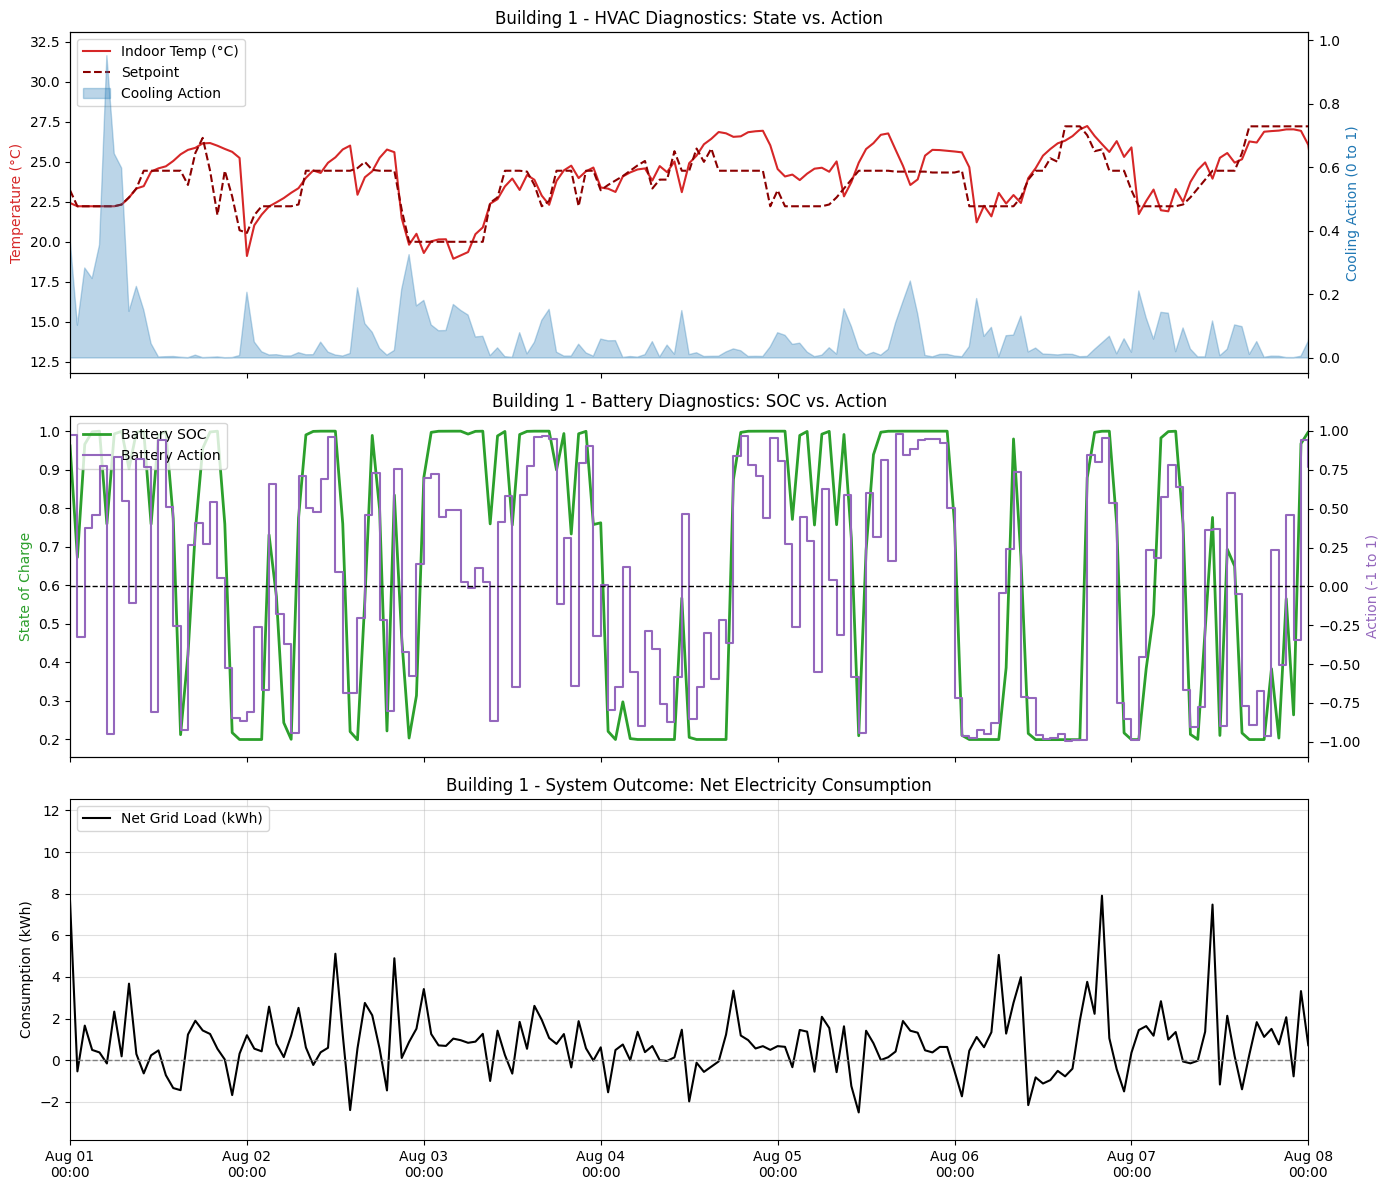

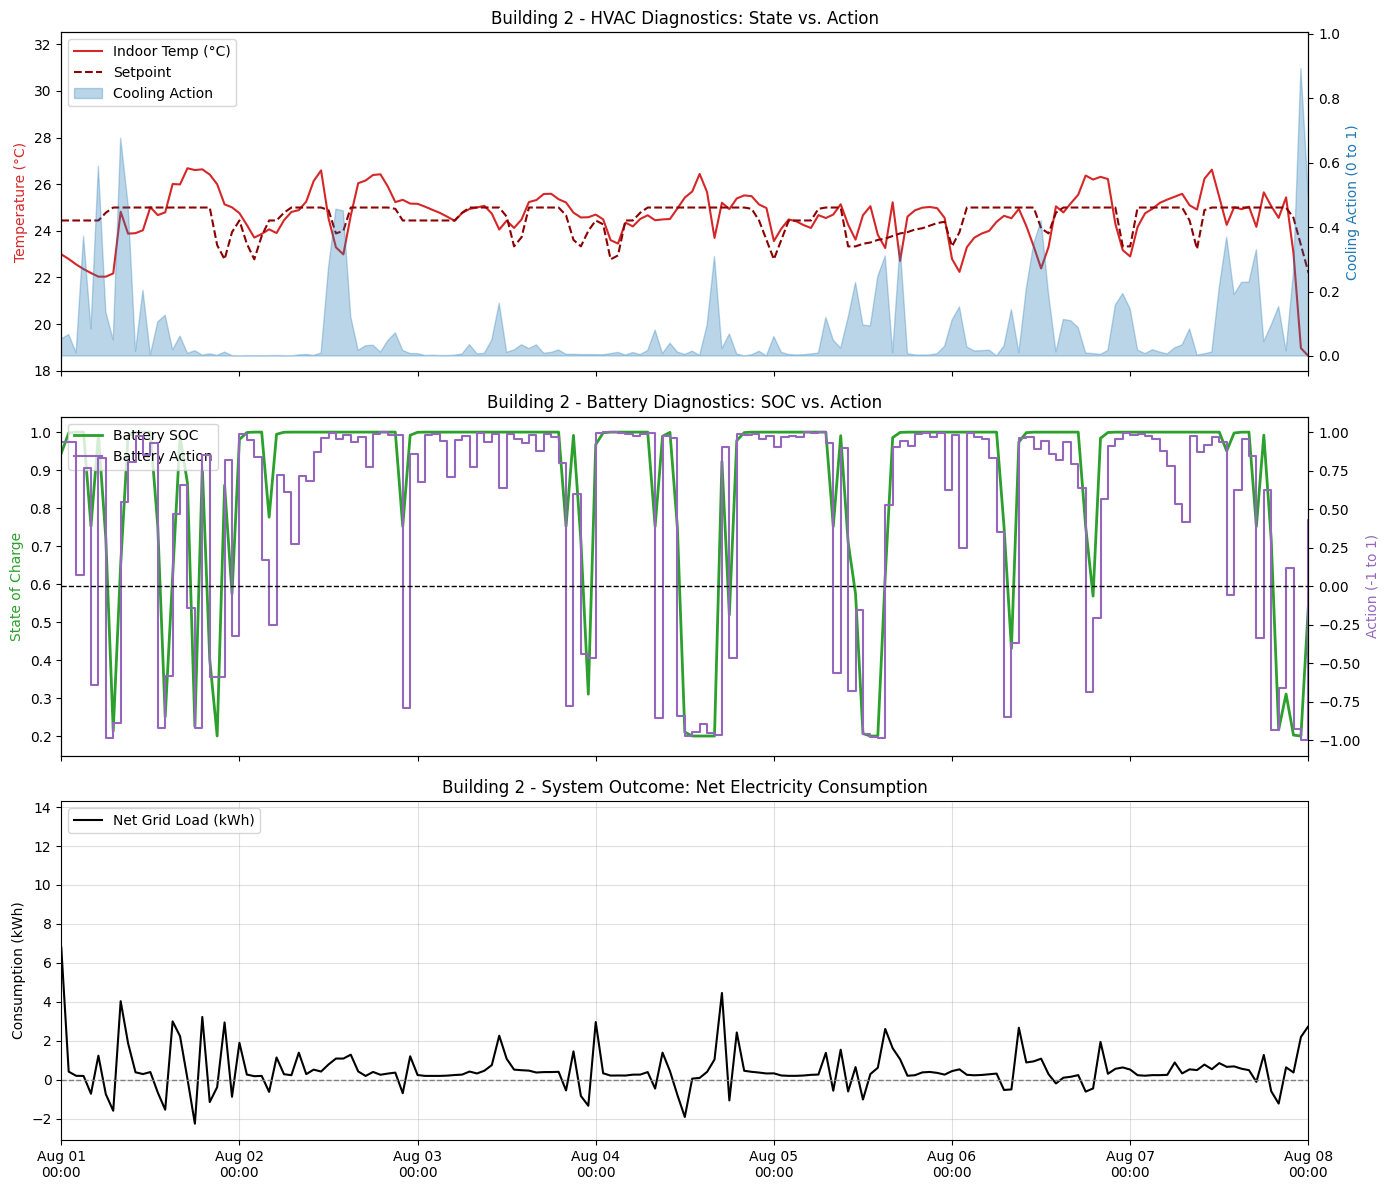

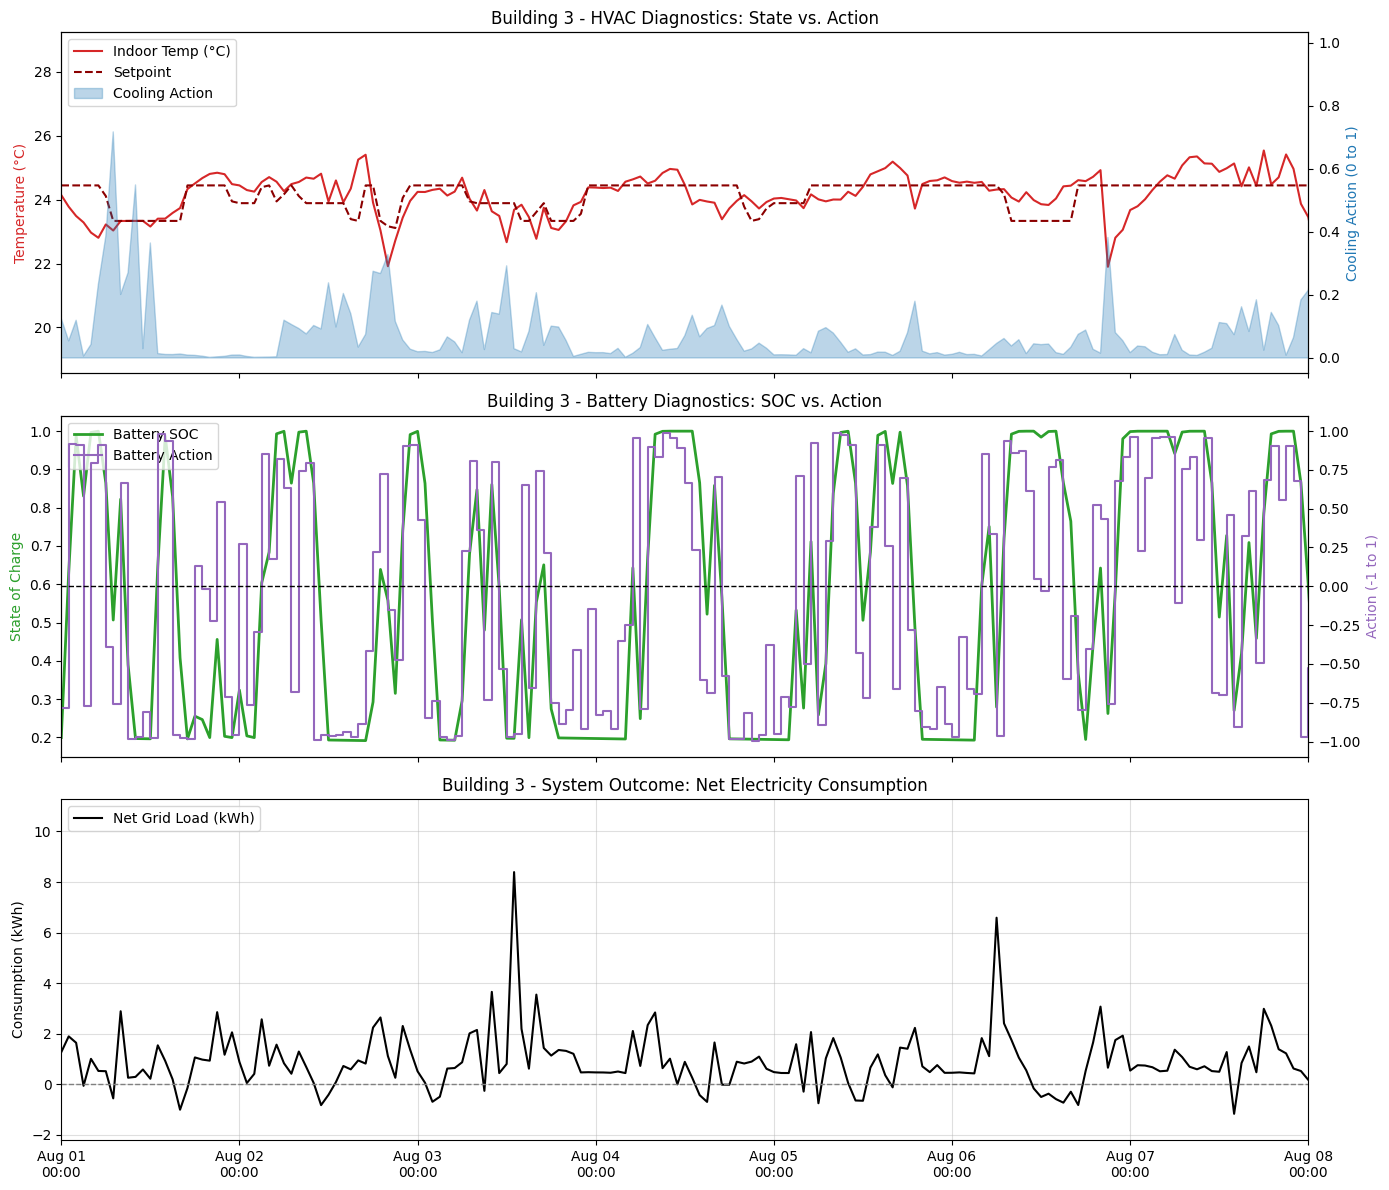

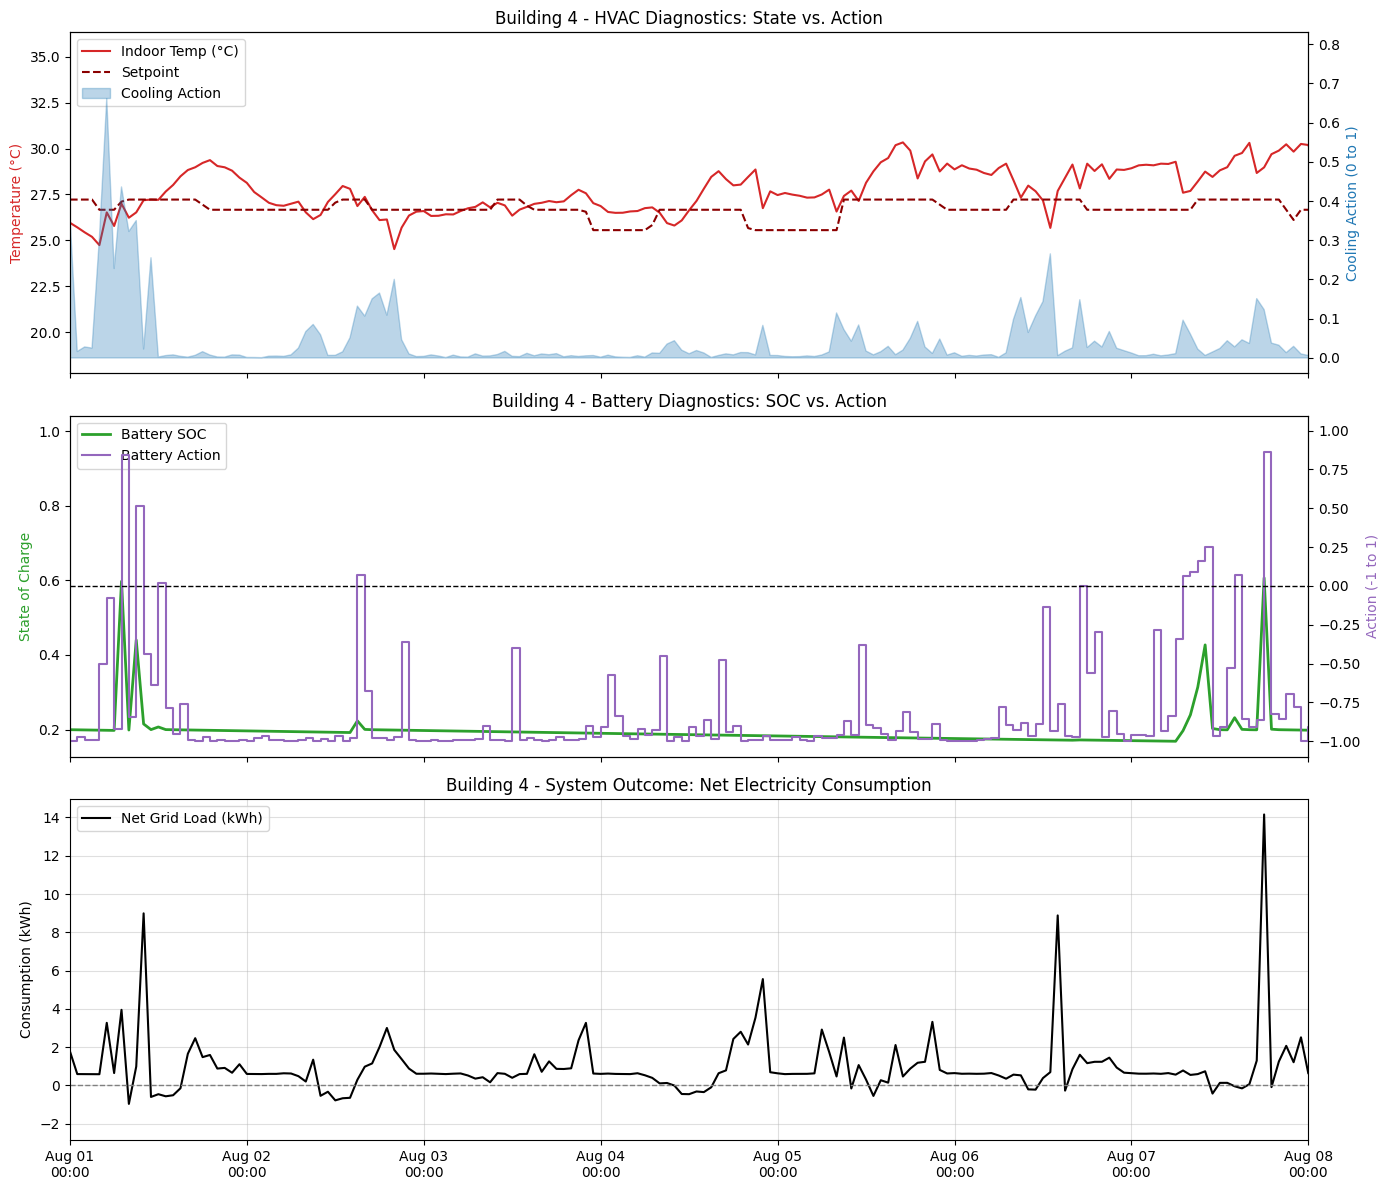

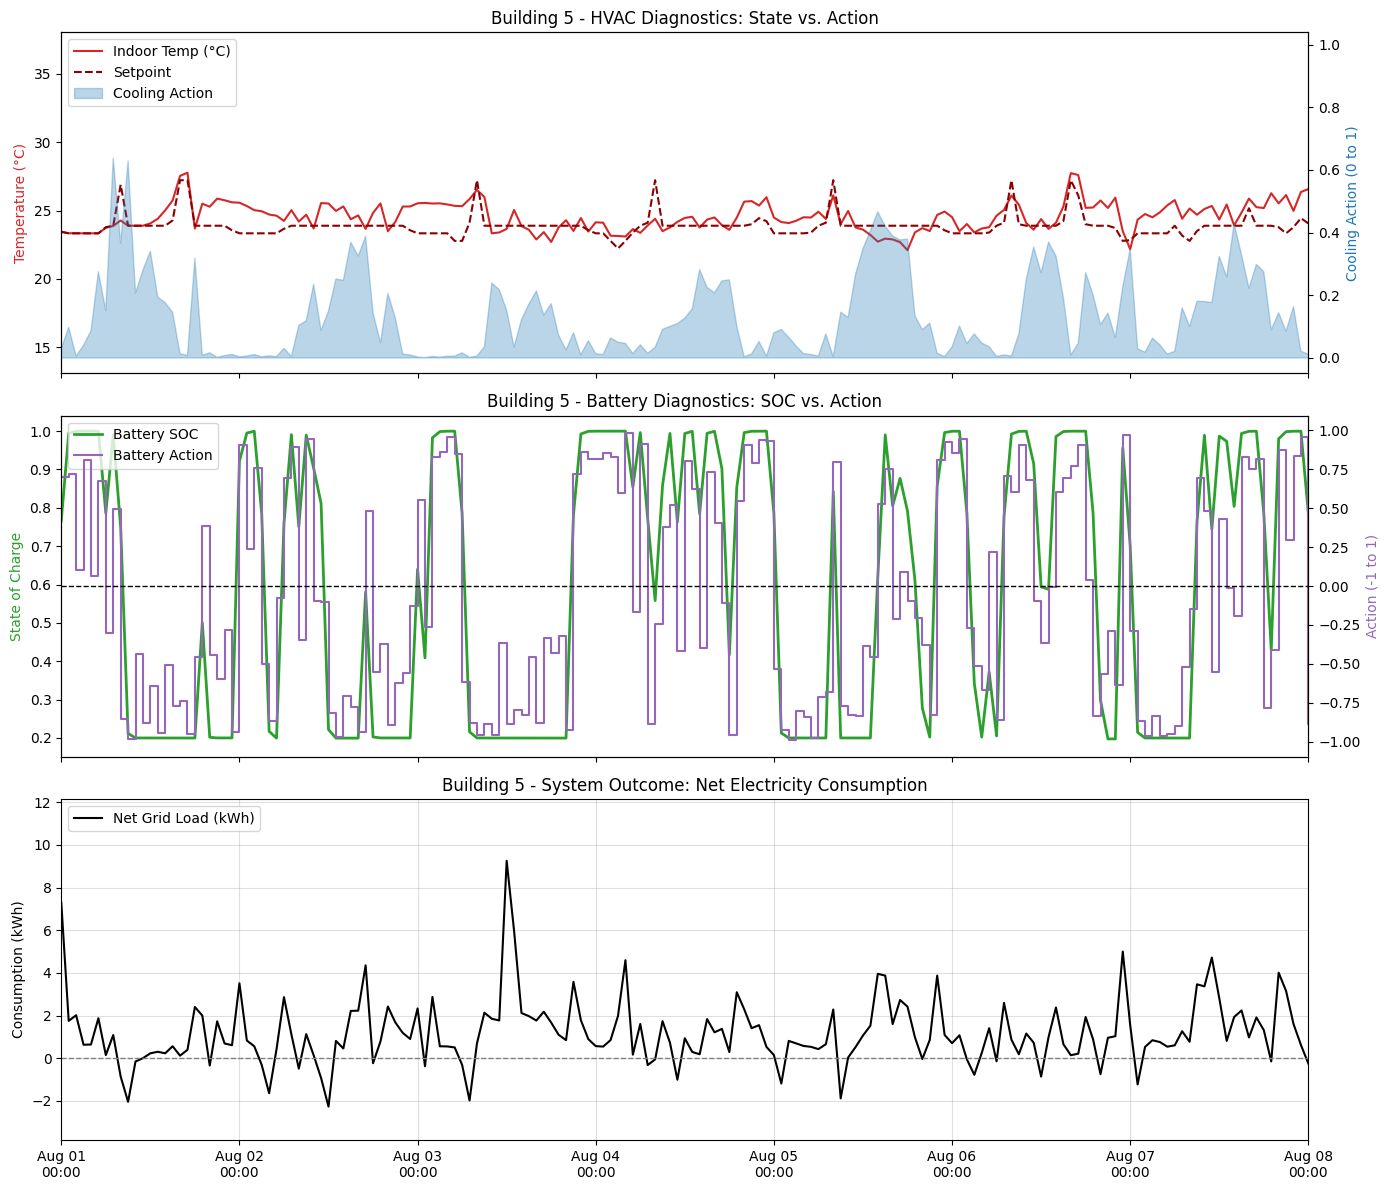

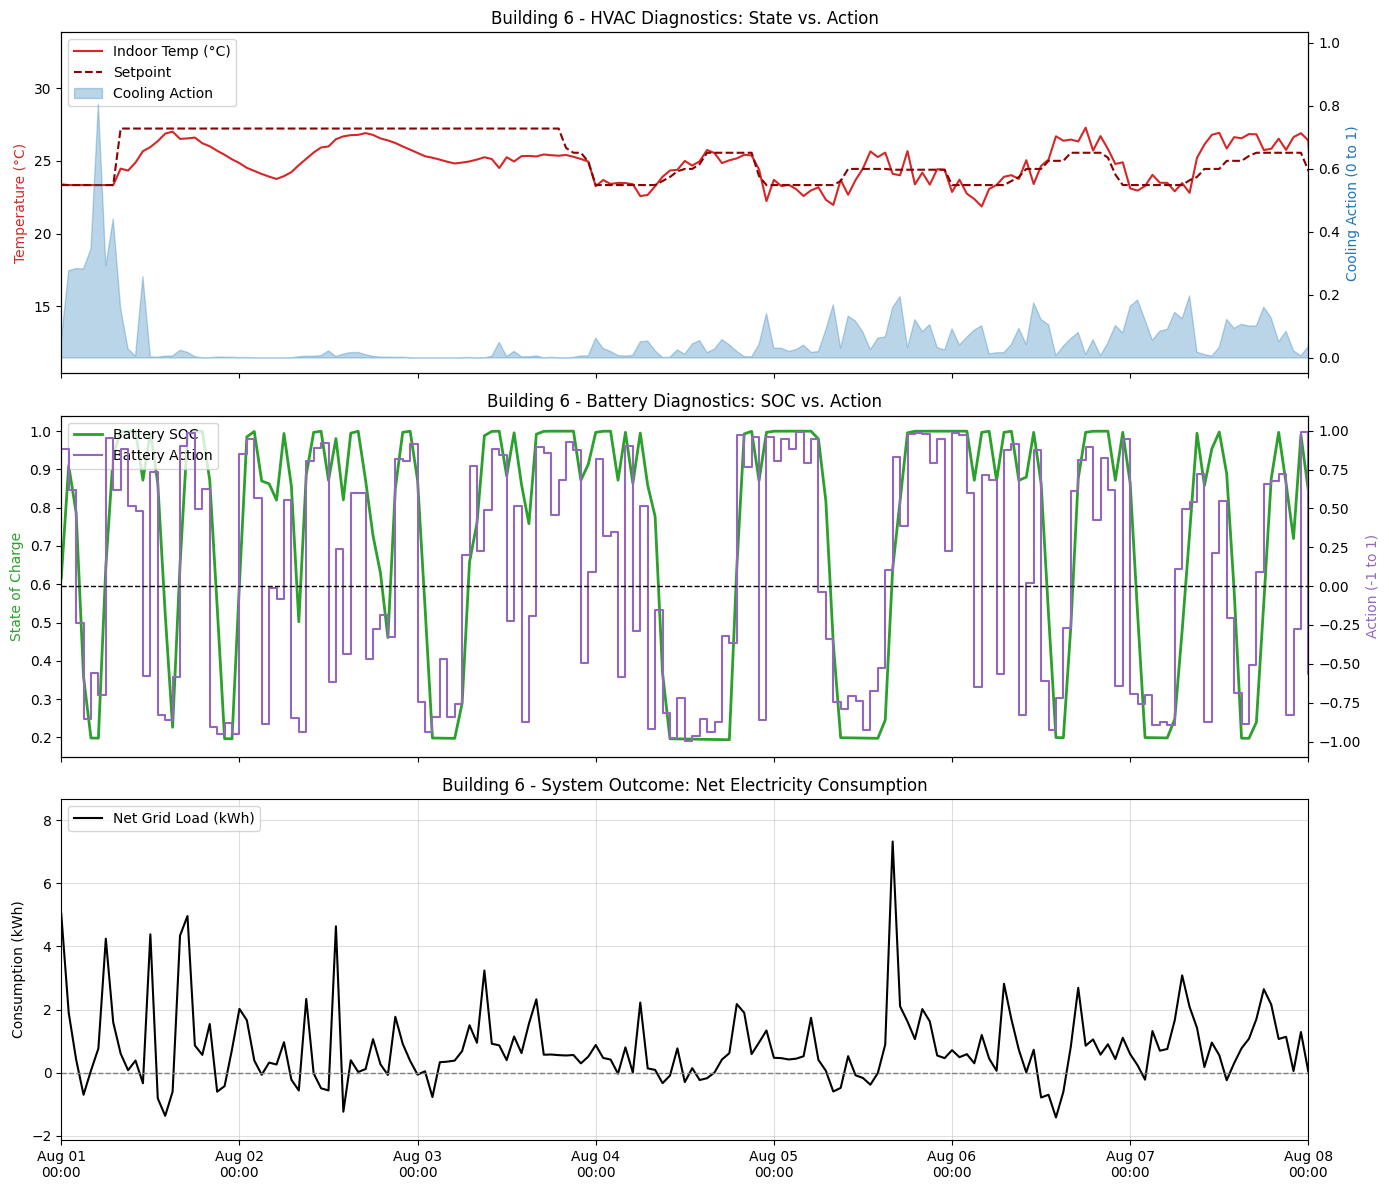

In [18]:
# ==========================================
# 5. Agent Behavior Plotting
# ==========================================
print("\n=== Generating Behavior Plots for Each House ===")

T = len(action_history)
start_date = pd.Timestamp("2023-08-01 00:00:00")
timestamps = pd.date_range(start=start_date, periods=T, freq="h")

# A centralized agent concatenates all building actions into a single array.
# For example, 6 houses with 3 actions each will have a shape of (T, 18).
num_actions_total = action_history.shape[1]
actions_per_building = num_actions_total // num_houses

# Loop and plot for every individual building
for b_idx in range(num_houses):
    building = env.unwrapped.buildings[b_idx]

    # 1. Telemetry specific to current building
    indoor_temp = building.indoor_dry_bulb_temperature[:T]
    setpoint = building.indoor_dry_bulb_temperature_cooling_set_point[:T]
    soc = building.electrical_storage.soc[:T]
    net_load = building.net_electricity_consumption[:T]

    # 2. Extract action indices mapped to this specific building
    # Assuming standard order: [DHW, Battery, Cooling]
    b_action_start = b_idx * actions_per_building
    bat_action_idx = b_action_start + 1
    cool_action_idx = b_action_start + 2

    fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    # --- Plot 1: HVAC ---
    color_temp = "tab:red"
    axs[0].plot(timestamps, indoor_temp, label="Indoor Temp (°C)", color=color_temp)
    axs[0].plot(timestamps, setpoint, label="Setpoint", color="darkred", linestyle="--")
    axs[0].set_ylabel("Temperature (°C)", color=color_temp)

    ax0_twin = axs[0].twinx()
    color_act = "tab:blue"
    ax0_twin.fill_between(
        timestamps,
        0,
        action_history[:, cool_action_idx],
        alpha=0.3,
        color=color_act,
        label="Cooling Action",
    )
    ax0_twin.set_ylabel("Cooling Action (0 to 1)", color=color_act)
    axs[0].set_title(f"Building {b_idx + 1} - HVAC Diagnostics: State vs. Action")

    l1, lab1 = axs[0].get_legend_handles_labels()
    l2, lab2 = ax0_twin.get_legend_handles_labels()
    axs[0].legend(l1 + l2, lab1 + lab2, loc="upper left")

    # --- Plot 2: Battery ---
    color_soc = "tab:green"
    axs[1].plot(timestamps, soc, label="Battery SOC", color=color_soc, linewidth=2)
    axs[1].set_ylabel("State of Charge", color=color_soc)

    ax1_twin = axs[1].twinx()
    color_b_act = "tab:purple"
    ax1_twin.step(
        timestamps,
        action_history[:, bat_action_idx],
        where="post",
        label="Battery Action",
        color=color_b_act,
    )
    ax1_twin.axhline(0, color="black", linewidth=1, linestyle="--")
    ax1_twin.set_ylabel("Action (-1 to 1)", color=color_b_act)
    axs[1].set_title(f"Building {b_idx + 1} - Battery Diagnostics: SOC vs. Action")

    l1, lab1 = axs[1].get_legend_handles_labels()
    l2, lab2 = ax1_twin.get_legend_handles_labels()
    axs[1].legend(l1 + l2, lab1 + lab2, loc="upper left")

    # --- Plot 3: Net Grid Load ---
    axs[2].plot(timestamps, net_load, label="Net Grid Load (kWh)", color="black")
    axs[2].axhline(0, color="gray", linewidth=1, linestyle="--")
    axs[2].set_ylabel("Consumption (kWh)")
    axs[2].set_title(f"Building {b_idx + 1} - System Outcome: Net Electricity Consumption")
    axs[2].legend(loc="upper left")
    axs[2].grid(True, alpha=0.4)

    axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
    plt.xticks(rotation=0)
    plt.xlim(timestamps[0], timestamps[168])
    plt.tight_layout()
    plt.show()


=== Generating District-Level Aggregated Plot ===


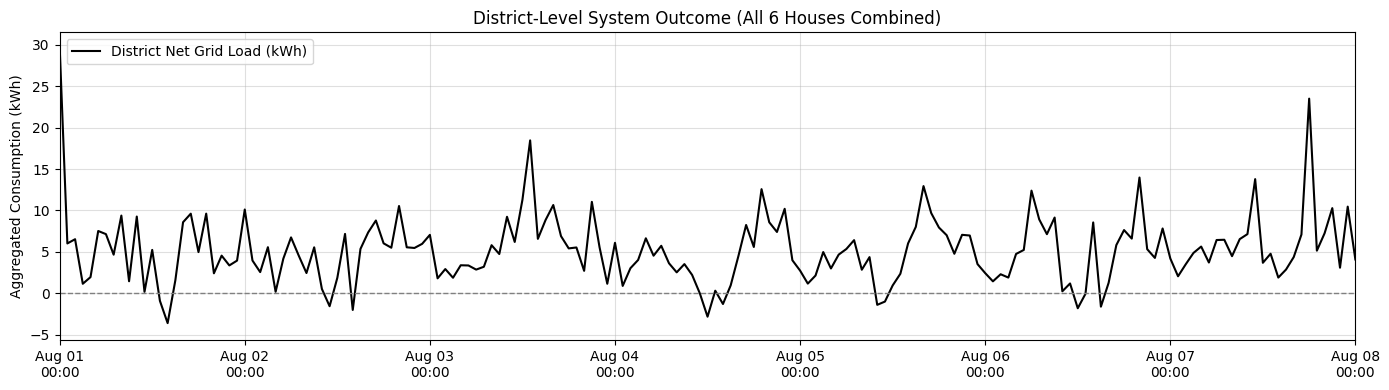

In [12]:
# ==========================================
# 6. Centralized District-Level Visualization
# ==========================================
# Because this is a centralized agent, looking at the entire district is highly relevant.

print("\n=== Generating District-Level Aggregated Plot ===")
fig, ax = plt.subplots(figsize=(14, 4))

# Summing up the grid loads of all houses
district_net_load = sum(
    [env.unwrapped.buildings[i].net_electricity_consumption[:T] for i in range(num_houses)]
)

ax.plot(timestamps, district_net_load, label="District Net Grid Load (kWh)", color="black")
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_ylabel("Aggregated Consumption (kWh)")
ax.set_title(f"District-Level System Outcome (All {num_houses} Houses Combined)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.4)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
plt.xticks(rotation=0)
plt.xlim(timestamps[0], timestamps[168])
plt.tight_layout()
plt.show()